Loads a trained STORM model + the preprocessed AnnDatas, projects every cell
into the shared latent space (``X_storm``), and then demonstrates the **two
distinct ways** of clustering this latent space — each one answers a
different biological question. All clustering logic lives in
:mod:`storm.clustering` so the same recipes are reusable in any analysis
script.

Mode A (CONCAT — modality-specific labels):
    Stack RNA + ATAC cells along axis 0 (``ad.concat([rna, atac])``), cluster
    once on the concatenated ``X_storm``, then split the labels back into
    RNA-specific and ATAC-specific assignments. *Each cell gets its own label
    from its own omics profile.* Useful for asking "do RNA and ATAC tell
    consistent spatial-domain stories?"

Mode B (JOINT — per-location label):
    Element-wise add the per-cell ``X_storm`` of paired RNA and ATAC
    (``X_joint = X_storm_rna + X_storm_atac``), cluster the resulting one-row-
    per-location matrix, sweep over multiple ``n_clusters`` and pick the
    best one by structure-marker AUC. *Each spatial location gets ONE label
    from its COMBINED RNA + ATAC profile.*

Run this with whatever ``.dill`` checkpoint you have:

* the short ``./dill_files/storm_tutorial.dill`` produced by tutorial 2
  (good for an API demo, but the embedding is intentionally noisy), OR
* a full-length training run that you'll plug into ``TRAINED_DILL`` below
  for publication-quality figures.

# STORM tutorial 3: clustering the joint latent space

A trained STORM model gives every cell a position in a shared latent space
(``adata.obsm["X_storm"]``). What you do *with* that latent space depends
on the question:

| Clustering mode                | What gets clustered                            | One label per … | Biological meaning |
| ------------------------------ | ---------------------------------------------- | --------------- | ------------------ |
| **CONCAT** (modality-specific) | ``ad.concat([rna, atac])`` row-stack of X_storm | cell (per modality) | "What spatial domain does this cell's *own* omics layer put it in?" Plotting per-modality reveals where RNA and ATAC tell different stories. |
| **JOINT** (per-location)       | ``rna.X_storm + atac.X_storm`` (element-wise)    | location        | "Given *both* RNA and ATAC at this location, what spatial domain is it?" The strongest single labeling. |

Both modes are implemented in :mod:`storm.clustering`. Mode A's labels are
computed once and the same vector is *visualised* on the RNA spatial map
and the ATAC spatial map separately. Mode B sweeps a range of ``n_clusters``
and uses an AUC criterion on curated anatomical-marker gene sets to pick
the best one.

In [1]:
import os
import sys

_REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), os.pardir)) \
    if "__file__" in globals() else os.path.abspath(os.path.join(os.getcwd(), os.pardir))
for _candidate in (_REPO_ROOT, os.getcwd()):
    if os.path.isdir(os.path.join(_candidate, "storm")) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc

import storm
from storm.clustering import (
    concat_clustering,
    joint_clustering_auc_select,
)
from storm.models import load_model

storm.plot.set_publication_params()

## 1. Parameters and paths

**Swap ``TRAINED_DILL`` for the path of a full-length checkpoint** to see
the actual published figures. Everything downstream in this notebook
(clustering, AUC selection, plots) re-runs against whatever model you
load.

In [2]:
TUTORIAL_OUT = "../artifacts/storm_tutorial"
PREP_DIR = f"{TUTORIAL_OUT}/preprocessed"
CLUSTER_DIR = f"{TUTORIAL_OUT}/clustered"
VIZ_DIR = f"{TUTORIAL_OUT}/viz"
os.makedirs(CLUSTER_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

PREP_RNA = f"{PREP_DIR}/rna_preprocessed.h5ad"
PREP_ATAC = f"{PREP_DIR}/atac_preprocessed.h5ad"

# >>> Change this to point at your full-length training checkpoint. <<<
TRAINED_DILL = "../dill_files/FINE_storm_P21P22_reftarg160_2tmp_RNAr_peak_source_repro.dill"

# Concat clustering: how many spatial domains to expect in each modality.
N_CLUSTERS_CONCAT = 16

# JOINT clustering: sweep over these candidate counts, pick best by AUC.
N_CLUSTERS_JOINT_SWEEP = [12, 14, 16, 18, 20]

# Marker-gene sets used by `joint_clustering_auc_select`. Each entry is a
# tissue structure → list of canonical markers; the AUC asks "can a single
# cluster be separated from the rest using only this gene set's mean
# expression?"
MARKER_DICT = {
    "Layer 2or3": ["Cux2"],
    "Layer 4": ["Rorb", "Cux1"],
    "Layer 6a": ["Tbr1", "Sulf1"],
    "Layer 6b": ["Cplx3", "Nxph3"],
    "Corpus Callosum": ["Mobp", "Sox10", "Mbp", "Tspan2", "Mog"],
    "Lateral Ventricle": ["Sox2"],
    "Calleja": ["Drd3"],
}

# Spatial plotting style.
SPOT_SIZE = 1.25

# Palette + cluster orderings used in the STORM manuscript figures (the
# `2 tmp` panel of `bench_viz_manual.ipynb`). These defaults assume you're
# running the bundled `FINE_storm_P21P22_*` checkpoint — the cluster IDs
# below are the ones that checkpoint emits. To use your own scheme, either:
#   * keep `PUBLISHED_COLORS_16` and replace the *_ORDER_* lists with the
#     permutation of cluster IDs you want, or
#   * set any of the three to `None` to fall back to numeric-id ordering
#     with scanpy's `vega_20` palette.
PUBLISHED_COLORS_16 = [
    "#b1cb99", "#83c4c5", "#e177a8", "#eeb6c4", "#8c2252", "#b45ea4", "#ee4593",
    "#3c4598", "#9483b9", "#7758a0",
    "#f4c447", "#e89239", "#fef492",
    "#aed8e6", "#f26b6c",
    "#4f6cb3",
]
# CONCAT clustering (per-modality labels): cluster id at position i gets
# `PUBLISHED_COLORS_16[i]`.
PUBLISHED_DOMAIN_ORDER_CONCAT = [
    10, 14, 3, 6, 1, 12, 13,
    7, 4, 5,
    2, 0, 15,
    11, 8,
    9
]
# JOINT clustering: same colour list, different cluster-to-colour pairing
PUBLISHED_DOMAIN_ORDER_JOINT = [
    9, 7, 3, 1, 2, 14, 15,
    5, 6, 12,
    11, 0, 10,
    13, 4,
    8,
]

## 2. Load the data and the trained model

Encoding each modality through the trained ``DataEncoder`` writes the
shared latent space into ``adata.obsm["X_storm"]``.

In [3]:
rna = ad.read_h5ad(PREP_RNA)
atac = ad.read_h5ad(PREP_ATAC)
print(f"RNA: {rna.n_obs} cells × {rna.n_vars} genes")
print(f"ATAC: {atac.n_obs} cells × {atac.n_vars} peaks")

storm_model = load_model(TRAINED_DILL)
rna.obsm["X_storm"] = storm_model.encode_data("rna", rna)
atac.obsm["X_storm"] = storm_model.encode_data("atac", atac)
print(f"Latent (RNA): {rna.obsm['X_storm'].shape}")
print(f"Latent (ATAC): {atac.obsm['X_storm'].shape}")

RNA: 11324 cells × 2871 genes
ATAC: 11324 cells × 4058 peaks
[INFO] autodevice: Using GPU 0 as computation device.


INFO:autodevice:Using GPU 0 as computation device.


Latent (RNA): (11324, 50)
Latent (ATAC): (11324, 50)


## 3. Mode A — CONCAT clustering (modality-specific labels)

:func:`storm.clustering.concat_clustering` stacks the two modalities,
runs the louvain-merge clustering recipe on the concatenated
``X_storm``, then splits the resulting labels back to each modality.
After this call both ``rna.obs['domain']`` and ``atac.obs['domain']``
share the same label *space* but each cell's label is determined by
*its own* row in ``X_storm``.

In [4]:
concat_clustering(rna, atac, n_clusters=N_CLUSTERS_CONCAT,
                  key="X_storm", method="louvain_merge")

print("RNA cluster counts:", rna.obs["domain"].value_counts().sort_index().to_dict())
print("ATAC cluster counts:", atac.obs["domain"].value_counts().sort_index().to_dict())

/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


RNA cluster counts: {0: 1256, 1: 1180, 2: 372, 3: 1173, 4: 1036, 5: 514, 6: 430, 7: 1225, 8: 313, 9: 61, 10: 593, 11: 822, 12: 798, 13: 571, 14: 596, 15: 384}
ATAC cluster counts: {0: 1196, 1: 1124, 2: 436, 3: 1151, 4: 1042, 5: 504, 6: 398, 7: 1194, 8: 324, 9: 42, 10: 662, 11: 834, 12: 756, 13: 689, 14: 551, 15: 421}


### Spatial visualisation per modality and per timepoint

Same cluster colour map for RNA and ATAC; per-modality plots reveal
where the two layers disagree.

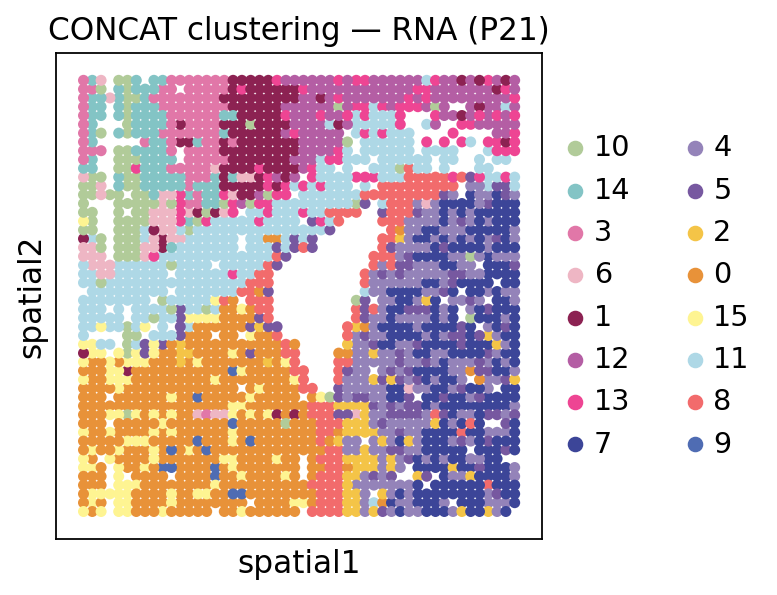

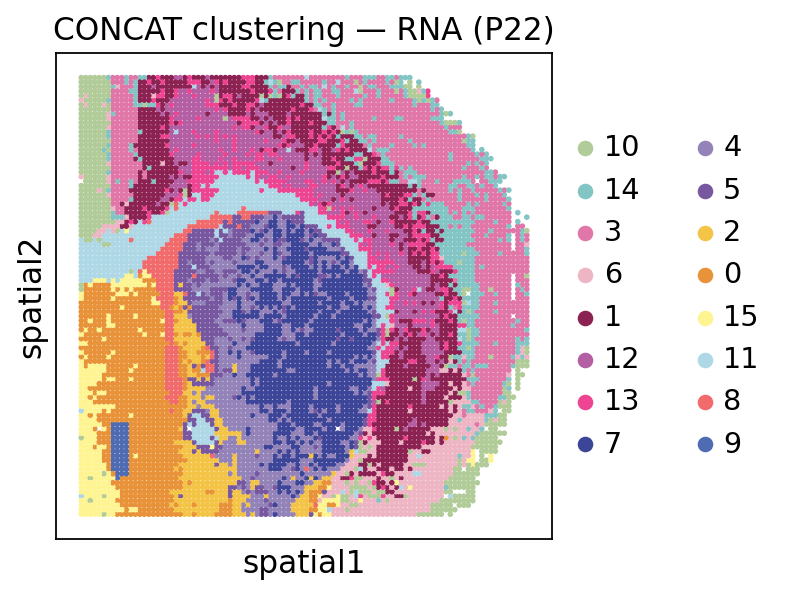

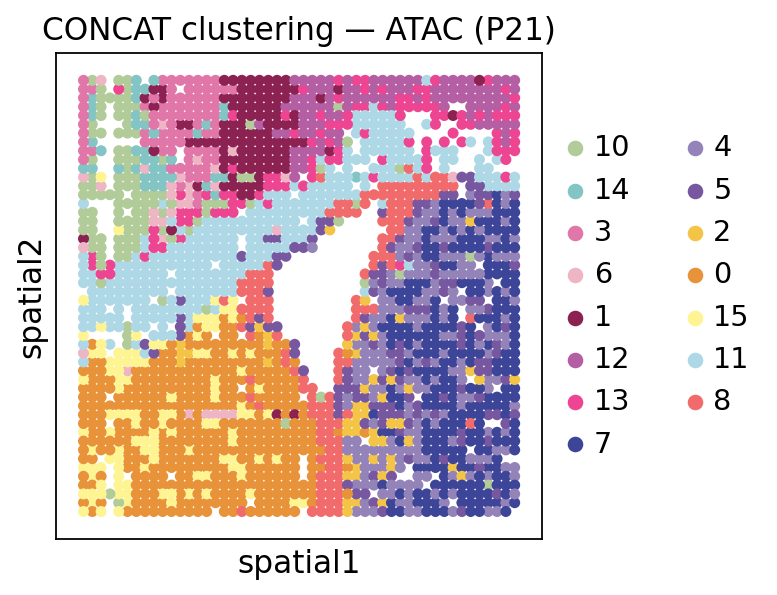

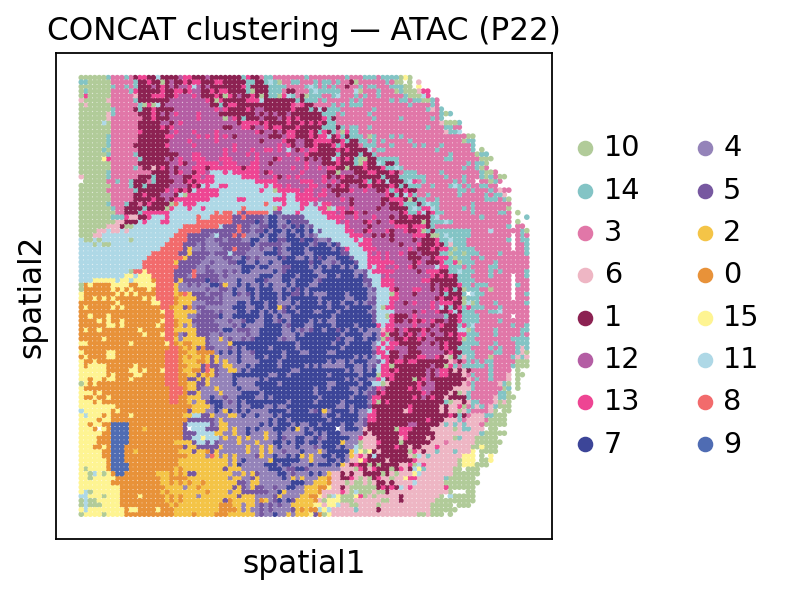

In [5]:
def apply_palette(adata, n_clusters, colors=PUBLISHED_COLORS_16,
                  domain_order=None):
    """Order the ``domain`` categories and apply a colour list.

    If ``domain_order`` is given and its entries exactly match the
    categories present, that curated cluster-id order is used (each
    cluster id at position ``i`` gets ``colors[i]``). Otherwise the
    categories are sorted numerically — pairing cluster id ``i`` with
    ``colors[i]`` — which is also what happens for any non-16-cluster
    case. Set ``colors=None`` to use scanpy's ``vega_20`` palette.
    """
    cats_present = list(adata.obs["domain"].cat.categories)
    use_curated = (
        domain_order is not None
        and len(domain_order) == len(cats_present)
        and set(domain_order) == set(cats_present)
    )
    if use_curated:
        cats = list(domain_order)
    else:
        if domain_order is not None:
            print(
                f"[apply_palette] domain_order doesn't match the categories "
                f"present (got {sorted(cats_present, key=int)}); falling back "
                "to numeric ordering."
            )
        cats = sorted(cats_present, key=int)
    adata.obs["domain"] = adata.obs["domain"].cat.set_categories(cats, ordered=True)
    palette = colors if (colors is not None and len(colors) >= len(cats)) \
        else sc.pl.palettes.vega_20_scanpy
    adata.uns["domain_colors"] = [palette[i % len(palette)] for i in range(len(cats))]


def plot_spatial_per_batch(adata, fname_prefix, title_stub,
                           batches=("P21", "P22")):
    for batch in batches:
        sub = adata[adata.obs["timepoint"] == batch].copy()
        cats_present = [c for c in adata.obs["domain"].cat.categories
                        if c in set(sub.obs["domain"].dropna().unique())]
        if not cats_present:
            continue
        sub.obs["domain"] = sub.obs["domain"].cat.set_categories(cats_present, ordered=True)
        cat_to_color = dict(zip(adata.obs["domain"].cat.categories,
                                adata.uns["domain_colors"]))
        palette = [cat_to_color[c] for c in cats_present]
        ax = sc.pl.spatial(
            sub, color="domain", spot_size=SPOT_SIZE, palette=palette,
            title=f"{title_stub} ({batch})", show=False, return_fig=False,
        )
        ax = ax[0] if isinstance(ax, (list, tuple)) else ax
        ax.invert_yaxis()
        ax.get_figure().savefig(f"{fname_prefix}_{batch}.pdf",
                                dpi=150, bbox_inches="tight")
        plt.show()


apply_palette(rna, N_CLUSTERS_CONCAT, domain_order=PUBLISHED_DOMAIN_ORDER_CONCAT)
apply_palette(atac, N_CLUSTERS_CONCAT, domain_order=PUBLISHED_DOMAIN_ORDER_CONCAT)
plot_spatial_per_batch(
    rna, f"{VIZ_DIR}/concat_rna_clustering{N_CLUSTERS_CONCAT}",
    title_stub="CONCAT clustering — RNA",
)
plot_spatial_per_batch(
    atac, f"{VIZ_DIR}/concat_atac_clustering{N_CLUSTERS_CONCAT}",
    title_stub="CONCAT clustering — ATAC",
)

## 4. Mode B — JOINT clustering (per-location label, AUC-selected ``n``)

:func:`storm.clustering.joint_clustering_auc_select` element-wise-adds
the two latent matrices, clusters the resulting one-row-per-location
matrix at every ``n`` in ``n_clusters_sweep``, and scores each ``n``
by asking — for each ``structure → markers`` entry in ``MARKER_DICT``
— "can a single cluster be separated from the rest using only the
mean expression of these markers?" The ``n`` that maximises the
average best-AUC across structures is returned along with the full
sweep table.

In [6]:
joint_best, auc_df, best_n = joint_clustering_auc_select(
    rna, atac,
    n_clusters_sweep=N_CLUSTERS_JOINT_SWEEP,
    marker_dict=MARKER_DICT,
    key="X_storm",
    method="louvain_merge",
    scoring_layer="counts",   # rna.layers['counts'] -> raw counts for AUC scoring
    increment=0.01
)

avg = auc_df.groupby("n_clusters")["best_auc"].mean().reset_index(name="avg_best_auc")
print(avg)
print(f"\nBest n_clusters (JOINT) by average AUC: {best_n}")

   n_clusters  avg_best_auc
0          12      0.801469
1          14      0.801292
2          16      0.806798
3          18      0.806188
4          20      0.804263

Best n_clusters (JOINT) by average AUC: 16


### JOINT clustering — AUC sweep curve and spatial plots

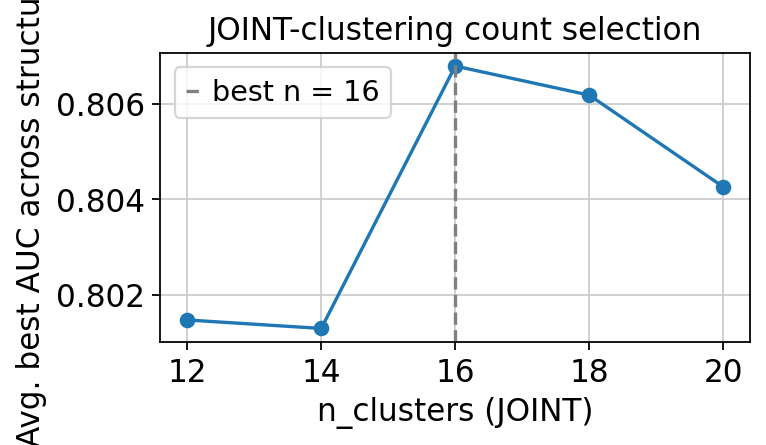

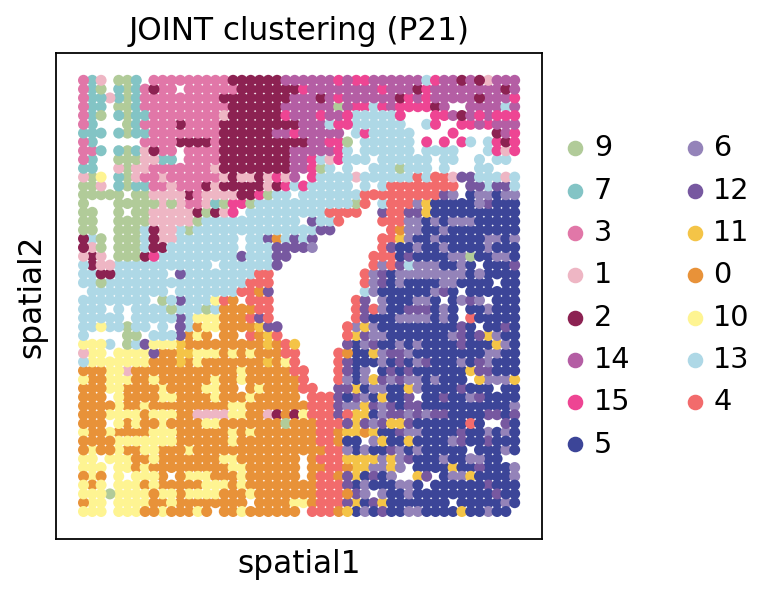

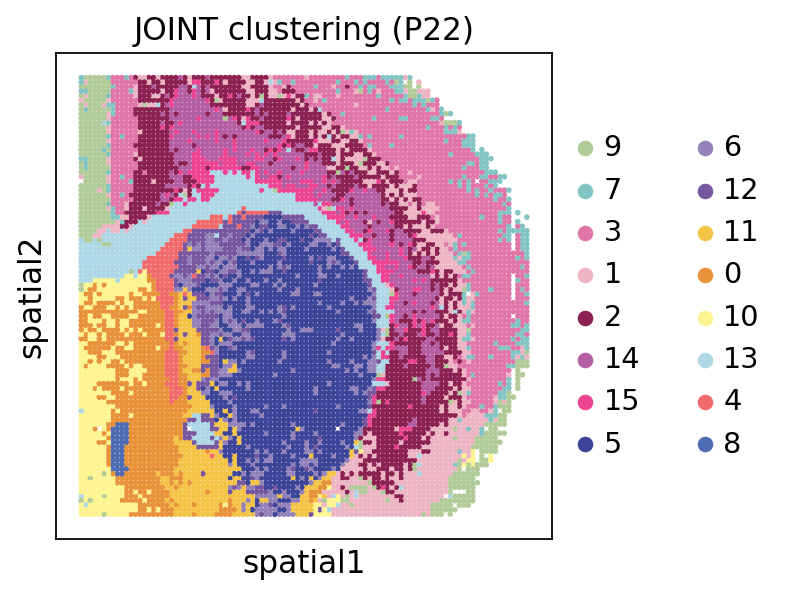

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(avg["n_clusters"], avg["avg_best_auc"], marker="o")
ax.axvline(best_n, ls="--", color="0.5", label=f"best n = {best_n}")
ax.set_xlabel("n_clusters (JOINT)")
ax.set_ylabel("Avg. best AUC across structures")
ax.set_title("JOINT-clustering count selection")
ax.legend()
fig.tight_layout()
fig.savefig(f"{VIZ_DIR}/joint_avg_best_auc_vs_n.pdf", dpi=150)
plt.show()

apply_palette(joint_best, best_n, domain_order=PUBLISHED_DOMAIN_ORDER_JOINT)
plot_spatial_per_batch(
    joint_best, f"{VIZ_DIR}/joint_clustering{best_n}",
    title_stub="JOINT clustering",
)

### UMAP of the JOINT latent

UMAP coordinates from ``X_storm`` for cells coloured by JOINT domain.
If clusters are heavily interleaved on the UMAP, the chosen
``n_clusters`` is probably too high.

/gpfs/gibbs/project/zhao/xc384/conda_envs/GLUE_GP/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


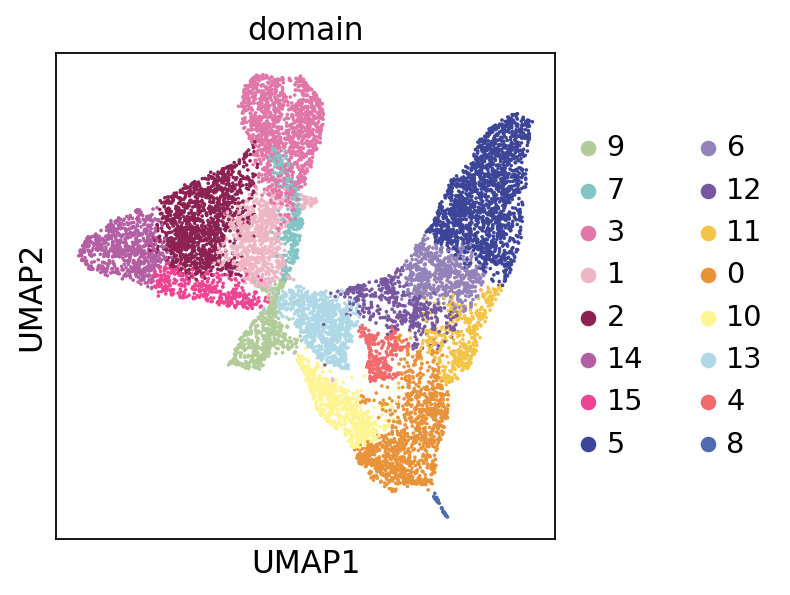

In [8]:
sc.pp.neighbors(joint_best, use_rep="X_storm", n_neighbors=30)
sc.tl.umap(joint_best)
sc.pl.umap(joint_best, color="domain", wspace=0.65, show=False)
plt.savefig(f"{VIZ_DIR}/joint_umap_domain{best_n}.pdf",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Save the clustered AnnDatas

Tutorial 4 (evaluation metrics) reads these back to compute the full
benchmark via :func:`storm.evaluation.benchmark`.

In [9]:
rna.write(f"{CLUSTER_DIR}/rna_concat{N_CLUSTERS_CONCAT}.h5ad", compression="gzip")
atac.write(f"{CLUSTER_DIR}/atac_concat{N_CLUSTERS_CONCAT}.h5ad", compression="gzip")
joint_best.write(f"{CLUSTER_DIR}/joint_clustering{best_n}.h5ad", compression="gzip")
auc_df.to_csv(f"{CLUSTER_DIR}/joint_auc_sweep.csv", index=False)

print(f"Wrote {CLUSTER_DIR}/rna_concat{N_CLUSTERS_CONCAT}.h5ad")
print(f"Wrote {CLUSTER_DIR}/atac_concat{N_CLUSTERS_CONCAT}.h5ad")
print(f"Wrote {CLUSTER_DIR}/joint_clustering{best_n}.h5ad")

Wrote ../artifacts/storm_tutorial/clustered/rna_concat16.h5ad
Wrote ../artifacts/storm_tutorial/clustered/atac_concat16.h5ad
Wrote ../artifacts/storm_tutorial/clustered/joint_clustering16.h5ad


## 6. Picking between the clustering modes

* **Need one canonical spatial-domain label per location?** Use the
  **JOINT** result (``joint_clustering{best_n}.h5ad``). This is the right
  label to feed into downstream "what's expressed in domain X" analyses
  and most published figures.
* **Need to check whether RNA and ATAC agree on the partition?** Compare
  ``rna_concat{N_CLUSTERS_CONCAT}.h5ad`` to ``atac_concat{N_CLUSTERS_CONCAT}.h5ad``
  — places where the two diverge are biologically interesting (e.g.,
  open chromatin at silent loci marks priming).
* **Need per-modality clustering quality metrics?** Tutorial 4 calls
  :func:`storm.evaluation.benchmark` to get FOSCTTM / MLISI / ARI /
  NMI / LISI / ASW / MAP / Moran's I / CLISIS in one tidy DataFrame.